# Static EEG Data Wrangling

This notebook walks through the static EEG preprocessing pipeline step by step so you can inspect intermediate outputs as you go. Each section explains what it does, shows the key inputs, and produces output that feeds the next step.

## Notebook goals

- Resolve the dataset root from local or Colab-friendly locations.
- Locate the example CHB-MIT and Siena EDF recordings.
- Load and preprocess each recording with the project workflow helpers.
- Split recordings into fixed-length epochs.
- Extract basic time-domain features and compare the two datasets.


## Execution notes and dataset contract

This section explains how the notebook discovers data and what folder layout it expects.

Functions used later: `resolve_dataset_root`, `get_example_dataset_paths`, `preprocess_eeg`, `make_epochs`, `extract_epoch_features`.

Expected dataset layout:

```text
<dataset root>/
  chbmit/chb01/chb01_01.edf
  siena/pn00/PN00-1.edf
```

Resolution order:

- `DATASET_ROOT_OVERRIDE` from the configuration cell below.
- `EEG_DATA_ROOT` from the environment.
- Local `./data` folders discovered upward from the current working directory.
- Google Drive locations when running in Colab.

Outputs from this notebook:

- Resolved dataset paths.
- Raw and cleaned EEG recording summaries.
- Epoch tensors for each dataset.
- Feature tables for CHB, Siena, and the combined benchmark dataframe.


## Configuration

This section keeps the settings most people are likely to tweak.

Inputs: an optional dataset root override, plus preprocessing and epoch parameters.

Output for the next step: notebook configuration variables used by the bootstrap and workflow cells.


In [ ]:
# Optional explicit dataset root. Leave as None to use EEG_DATA_ROOT, local ./data,
# or Colab / Google Drive discovery.
DATASET_ROOT_OVERRIDE = None

# In Colab, allow the dataset resolver to mount Google Drive when the dataset is not local.
AUTO_MOUNT_GOOGLE_DRIVE = True

# Epoching and preprocessing configuration.
EPOCH_DURATION_SEC = 2.0
EPOCH_OVERLAP_SEC = 1.0
TARGET_SFREQ = 256

## Repo bootstrap

This step makes the `src/` package importable whether the notebook is running locally or in Google Colab.

Inputs: the current working directory and the optional `EEG_PROJECT_ROOT` environment variable.

Output for the next step: a resolved source path added to `sys.path`, plus helper functions for cleaner table displays.


In [ ]:
from pathlib import Path
import os
import sys
import tempfile
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))


def running_in_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def is_repo_root(candidate: Path) -> bool:
    return (candidate / "pyproject.toml").exists() and (
        candidate / "src" / "eeg_project"
    ).exists()


def dedupe_paths(paths):
    deduped = []
    seen = set()
    for path in paths:
        key = str(path)
        if key not in seen:
            deduped.append(path)
            seen.add(key)
    return deduped


def candidate_repo_roots():
    roots = []

    env_root = os.environ.get("EEG_PROJECT_ROOT")
    if env_root:
        roots.append(Path(env_root).expanduser())

    roots.extend([Path.cwd(), *Path.cwd().parents])

    if running_in_colab():
        roots.extend(
            [
                Path("/content"),
                Path("/content/eeg-Spr2026-CSCI7090"),
                Path("/content/drive/MyDrive"),
                Path("/content/drive/MyDrive/eeg-Spr2026-CSCI7090"),
                Path("/content/drive/MyDrive/Colab Notebooks"),
                Path("/content/drive/Shareddrives"),
            ]
        )

    roots.extend([Path.home(), Path.home() / "Developer", Path.home() / "Documents"])
    return dedupe_paths(path.expanduser() for path in roots)


def discover_repo_root() -> Path:
    checked = []

    for root in candidate_repo_roots():
        for candidate in [root, *root.parents]:
            checked.append(candidate)
            if is_repo_root(candidate):
                return candidate.resolve()

    search_roots = [root for root in candidate_repo_roots() if root.exists()]
    matches_checked = 0
    for search_root in search_roots:
        for pyproject_file in search_root.rglob("pyproject.toml"):
            matches_checked += 1
            candidate = pyproject_file.parent
            checked.append(candidate)
            if is_repo_root(candidate):
                return candidate.resolve()
            if matches_checked >= 300:
                break
        if matches_checked >= 300:
            break

    checked_display = "\n".join(f" - {path}" for path in dedupe_paths(checked)[:20])
    raise ModuleNotFoundError(
        "Could not locate the repository root.\n"
        "Local: open this notebook from the project workspace or set EEG_PROJECT_ROOT.\n"
        "Colab: clone the repo into /content or set EEG_PROJECT_ROOT to the mounted Drive repo path.\n\n"
        f"Checked:\n{checked_display}"
    )


def ensure_repo_src_on_path() -> Path:
    repo_root = discover_repo_root()
    src_dir = (repo_root / "src").resolve()
    resolved = str(src_dir)
    if resolved not in sys.path:
        sys.path.insert(0, resolved)
    return src_dir


def display_df(title: str, df: pd.DataFrame) -> None:
    display(Markdown(f"### {title}"))
    display(df)


def summarize_raw(raw, dataset_name: str, stage: str) -> dict:
    duration_sec = raw.n_times / raw.info["sfreq"] if raw.info["sfreq"] else np.nan
    return {
        "dataset": dataset_name,
        "stage": stage,
        "sampling_rate_hz": float(raw.info["sfreq"]),
        "n_channels": int(len(raw.ch_names)),
        "n_samples": int(raw.n_times),
        "duration_sec": round(float(duration_sec), 2),
        "first_channels": ", ".join(raw.ch_names[:6]),
    }


def summarize_epochs(
    dataset_name: str, epoch_array: np.ndarray, sampling_rate: float
) -> dict:
    return {
        "dataset": dataset_name,
        "epoch_count": int(epoch_array.shape[0]),
        "channel_count": int(epoch_array.shape[1]),
        "samples_per_epoch": int(epoch_array.shape[2]),
        "epoch_duration_sec": round(epoch_array.shape[2] / sampling_rate, 2),
        "sampling_rate_hz": float(sampling_rate),
    }


pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="mne")

src_dir = ensure_repo_src_on_path()
print("Using source path:", src_dir)
print("Running in Colab:", running_in_colab())

Using source path: /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/src
Running in Colab: False


## Step 1: Resolve the dataset root

This step finds the directory that directly contains both `chbmit/` and `siena/`.

Function used: `resolve_dataset_root`.

Inputs: `DATASET_ROOT_OVERRIDE` and `AUTO_MOUNT_GOOGLE_DRIVE`.

Output for the next step: `dataset_root` and a trace of every path that was checked.


In [ ]:
from eeg_project.common.paths import resolve_dataset_root
from eeg_project.static import get_example_dataset_paths

if DATASET_ROOT_OVERRIDE:
    os.environ["EEG_DATA_ROOT"] = str(Path(DATASET_ROOT_OVERRIDE).expanduser())

dataset_root, checked_paths = resolve_dataset_root(
    DATASET_ROOT_OVERRIDE,
    mount_google_drive_if_needed=AUTO_MOUNT_GOOGLE_DRIVE,
)

print("Resolved dataset root:", dataset_root)
checked_paths_df = pd.DataFrame({"checked_path": [str(path) for path in checked_paths]})
display_df("Dataset Root Search Trace", checked_paths_df)

Resolved dataset root: /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data


### Dataset Root Search Trace

,checked_path
0,/Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data


## Step 2: Locate the example recordings

This step resolves the exact EDF files used in the benchmark workflow.

Function used: `get_example_dataset_paths`.

Input: `dataset_root`.

Output for the next step: `chb_path` and `siena_path`, which are loaded as MNE raw objects.


In [ ]:
resolved_root, chb_path, siena_path = get_example_dataset_paths(dataset_root)

recordings_df = pd.DataFrame(
    [
        {"dataset": "CHB", "path": str(chb_path), "exists": chb_path.exists()},
        {"dataset": "Siena", "path": str(siena_path), "exists": siena_path.exists()},
    ]
)

print("Dataset root used for loading:", resolved_root)
display_df("Example Recording Paths", recordings_df)

Dataset root used for loading: /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data


### Example Recording Paths

,dataset,path,exists
0,CHB,/Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data/chbmit/chb01/chb01_0...,True
1,Siena,/Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data/siena/pn00/PN00-1.edf,True


## Step 3: Load raw EDF recordings

This step reads the CHB and Siena example files into raw MNE objects before preprocessing.

Function used: `mne.io.read_raw_edf`.

Inputs: `chb_path` and `siena_path`.

Output for the next step: `raw_chb` and `raw_siena`, plus baseline summaries that make preprocessing changes easier to interpret.


In [ ]:
import mne

mne.set_log_level("WARNING")

raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
raw_siena = mne.io.read_raw_edf(siena_path, preload=False, verbose=False)

raw_before_df = pd.DataFrame(
    [
        summarize_raw(raw_chb, "CHB", "raw_loaded"),
        summarize_raw(raw_siena, "Siena", "raw_loaded"),
    ]
)

display_df("Raw Recording Summary", raw_before_df)

### Raw Recording Summary

,dataset,stage,sampling_rate_hz,n_channels,n_samples,duration_sec,first_channels
0,CHB,raw_loaded,256.0,23,62720,245.0,"FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3"
1,Siena,raw_loaded,512.0,35,1344000,2625.0,"EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7"


## Step 4: Preprocess each recording

This step removes non-EEG channels, handles duplicate MNE-generated names, resamples to a shared frequency, and applies the project bandpass and notch filters.

Function used: `preprocess_eeg`.

Inputs: `raw_chb`, `raw_siena`, and `TARGET_SFREQ`.

Output for the next step: `raw_chb_clean` and `raw_siena_clean`, ready for fixed-length epoch creation.


In [ ]:
from eeg_project.static import preprocess_eeg

raw_chb_clean = preprocess_eeg(raw_chb, "CHB", target_sfreq=TARGET_SFREQ)
raw_siena_clean = preprocess_eeg(raw_siena, "Siena", target_sfreq=TARGET_SFREQ)

raw_after_df = pd.DataFrame(
    [
        summarize_raw(raw_chb_clean, "CHB", "preprocessed"),
        summarize_raw(raw_siena_clean, "Siena", "preprocessed"),
    ]
)

preprocessing_comparison_df = pd.concat(
    [raw_before_df, raw_after_df], ignore_index=True
)
display_df(
    "Preprocessing Summary Before And After Cleaning", preprocessing_comparison_df
)

### Preprocessing Summary Before And After Cleaning

,dataset,stage,sampling_rate_hz,n_channels,n_samples,duration_sec,first_channels
0,CHB,raw_loaded,256.0,23,62720,245.0,"FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3"
1,Siena,raw_loaded,512.0,35,1344000,2625.0,"EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7"
2,CHB,preprocessed,256.0,22,62720,245.0,"FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3"
3,Siena,preprocessed,256.0,31,672000,2625.0,"EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7"


In [ ]:
channel_preview_df = pd.DataFrame(
    [
        {
            "dataset": "CHB",
            "stage": "preprocessed",
            "channel_preview": ", ".join(raw_chb_clean.ch_names[:10]),
        },
        {
            "dataset": "Siena",
            "stage": "preprocessed",
            "channel_preview": ", ".join(raw_siena_clean.ch_names[:10]),
        },
    ]
)

display_df("Preprocessed Channel Preview", channel_preview_df)

### Preprocessed Channel Preview

,dataset,stage,channel_preview
0,CHB,preprocessed,"FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, FP2-F4, F4-C4"
1,Siena,preprocessed,"EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7, EEG T3, EEG T5, EEG Fc1, EEG Fc5"


## Step 5: Create fixed-length epochs

This step splits each cleaned recording into overlapping windows that can be summarized with tabular features.

Function used: `make_epochs`.

Inputs: `raw_chb_clean`, `raw_siena_clean`, `EPOCH_DURATION_SEC`, and `EPOCH_OVERLAP_SEC`.

Output for the next step: epoch objects and NumPy arrays shaped `(epochs, channels, samples)`.


In [ ]:
from eeg_project.static import make_epochs

epochs_chb = make_epochs(
    raw_chb_clean, duration=EPOCH_DURATION_SEC, overlap=EPOCH_OVERLAP_SEC
)
epochs_siena = make_epochs(
    raw_siena_clean, duration=EPOCH_DURATION_SEC, overlap=EPOCH_OVERLAP_SEC
)

x_chb = epochs_chb.get_data()
x_siena = epochs_siena.get_data()

epoch_summary_df = pd.DataFrame(
    [
        summarize_epochs("CHB", x_chb, raw_chb_clean.info["sfreq"]),
        summarize_epochs("Siena", x_siena, raw_siena_clean.info["sfreq"]),
    ]
)

display_df("Epoch Summary", epoch_summary_df)

### Epoch Summary

,dataset,epoch_count,channel_count,samples_per_epoch,epoch_duration_sec,sampling_rate_hz
0,CHB,244,22,512,2.0,256.0
1,Siena,2624,31,512,2.0,256.0


## Step 6: Extract time-domain features

This step converts each epoch tensor into a flat table with simple descriptive statistics.

Function used: `extract_epoch_features`.

Inputs: `x_chb`, `x_siena`, `EPOCH_DURATION_SEC`, `EPOCH_OVERLAP_SEC`, and each recording's sampling rate.

Output for the next step: `df_chb` and `df_siena`, which are concatenated into the final benchmark feature table.


In [ ]:
from eeg_project.static import extract_epoch_features

df_chb = extract_epoch_features(
    x_chb,
    "CHB",
    raw_chb_clean.info["sfreq"],
    duration=EPOCH_DURATION_SEC,
    overlap=EPOCH_OVERLAP_SEC,
)
df_siena = extract_epoch_features(
    x_siena,
    "Siena",
    raw_siena_clean.info["sfreq"],
    duration=EPOCH_DURATION_SEC,
    overlap=EPOCH_OVERLAP_SEC,
)

df_all = pd.concat([df_chb, df_siena], ignore_index=True)
print("Combined feature table shape:", df_all.shape)

Combined feature table shape: (2868, 14)


In [ ]:
feature_schema = {
    "dataset": "Source dataset label for each epoch.",
    "epoch_index": "Zero-based epoch number within the recording.",
    "epoch_start_sec": "Approximate epoch start time computed from duration and overlap.",
    "mean": "Mean amplitude across the flattened epoch.",
    "std": "Standard deviation across the flattened epoch.",
    "min": "Minimum value in the flattened epoch.",
    "max": "Maximum value in the flattened epoch.",
    "range": "Difference between max and min.",
    "energy": "Sum of squared amplitudes.",
    "rms": "Root-mean-square amplitude.",
    "abs_mean": "Mean absolute amplitude.",
    "channel_count": "Number of channels in the epoch tensor.",
    "samples_per_epoch": "Samples per channel in each epoch.",
    "sampling_rate": "Sampling rate used during feature extraction.",
}

feature_schema_df = pd.DataFrame(
    [
        {
            "column": column,
            "dtype": str(df_all[column].dtype),
            "description": description,
        }
        for column, description in feature_schema.items()
    ]
)

display_df("Feature Schema", feature_schema_df)
display_df("Feature Table Preview", df_all.head(10))

### Feature Schema

,column,dtype,description
0,dataset,str,Source dataset label for each epoch.
1,epoch_index,int64,Zero-based epoch number within the recording.
2,epoch_start_sec,float64,Approximate epoch start time computed from duration and overlap.
3,mean,float64,Mean amplitude across the flattened epoch.
4,std,float64,Standard deviation across the flattened epoch.
5,min,float64,Minimum value in the flattened epoch.
6,max,float64,Maximum value in the flattened epoch.
7,range,float64,Difference between max and min.
8,energy,float64,Sum of squared amplitudes.
9,rms,float64,Root-mean-square amplitude.


### Feature Table Preview

,dataset,epoch_index,epoch_start_sec,mean,std,min,max,range,energy,rms,abs_mean,channel_count,samples_per_epoch,sampling_rate
0,CHB,0,0.0,1.469223e-05,0.000062,-0.000148,0.000324,0.000472,0.000045,0.000063,0.000043,22,512,256.0
1,CHB,1,1.0,-1.200434e-06,0.000031,-0.000171,0.000236,0.000406,0.000011,0.000031,0.000023,22,512,256.0
2,CHB,2,2.0,-8.916804e-07,0.000028,-0.000171,0.000236,0.000406,0.000009,0.000028,0.000020,22,512,256.0
3,CHB,3,3.0,4.274892e-07,0.000025,-0.000128,0.000154,0.000282,0.000007,0.000025,0.000019,22,512,256.0
4,CHB,4,4.0,5.126279e-07,0.000025,-0.000122,0.000130,0.000251,0.000007,0.000025,0.000019,22,512,256.0
5,CHB,5,5.0,3.785531e-06,0.000040,-0.000339,0.000295,0.000634,0.000018,0.000040,0.000024,22,512,256.0
6,CHB,6,6.0,-1.774221e-06,0.000052,-0.000339,0.000295,0.000634,0.000030,0.000052,0.000031,22,512,256.0
7,CHB,7,7.0,-4.354279e-06,0.000040,-0.000309,0.000155,0.000464,0.000018,0.000040,0.000025,22,512,256.0
8,CHB,8,8.0,2.869705e-06,0.000049,-0.000209,0.000476,0.000685,0.000027,0.000049,0.000026,22,512,256.0
9,CHB,9,9.0,-1.531660e-06,0.000072,-0.000467,0.000476,0.000942,0.000059,0.000072,0.000040,22,512,256.0


## Step 7: Summarize and compare the feature table

This step combines the two datasets into one benchmark table and checks how their aggregate feature values differ.

Functions used: pandas `groupby` operations and simple plotting.

Input: `df_all`.

Output: summary tables and plots that confirm the pipeline produced a usable feature matrix for downstream benchmarking.


In [ ]:
summary_df = (
    df_all.groupby("dataset")[["mean", "std", "energy", "rms", "abs_mean"]]
    .agg(["mean", "median"])
    .round(8)
)
summary_df.columns = [f"{feature}_{stat}" for feature, stat in summary_df.columns]
summary_df = summary_df.reset_index()

dataset_size_df = df_all.groupby("dataset").size().reset_index(name="epoch_rows")

display_df("Dataset Row Counts", dataset_size_df)
display_df("Grouped Feature Summary", summary_df)

### Dataset Row Counts

,dataset,epoch_rows
0,CHB,244
1,Siena,2624


### Grouped Feature Summary

,dataset,mean_mean,mean_median,std_mean,std_median,energy_mean,energy_median,rms_mean,rms_median,abs_mean_mean,abs_mean_median
0,CHB,5.000000e-08,-1.100000e-07,0.000032,0.000029,0.000014,0.000010,0.000032,0.000029,0.000021,0.000019
1,Siena,0.000000e+00,0.000000e+00,0.000072,0.000068,0.000090,0.000073,0.000072,0.000068,0.000020,0.000017


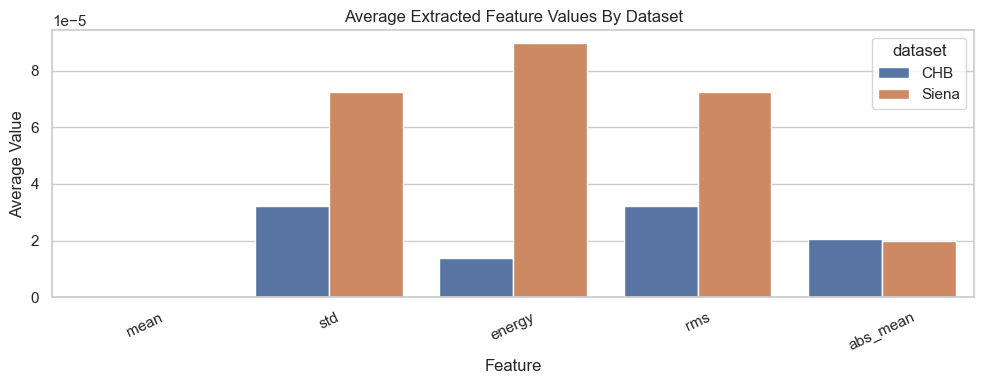

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plot_df = (
    df_all.groupby("dataset")[["mean", "std", "energy", "rms", "abs_mean"]]
    .mean()
    .reset_index()
    .melt(id_vars="dataset", var_name="feature", value_name="value")
)

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="feature", y="value", hue="dataset")
plt.title("Average Extracted Feature Values By Dataset")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
results = {
    "dataset_root": dataset_root,
    "chb_path": chb_path,
    "siena_path": siena_path,
    "raw_chb_clean": raw_chb_clean,
    "raw_siena_clean": raw_siena_clean,
    "epochs_chb": epochs_chb,
    "epochs_siena": epochs_siena,
    "x_chb": x_chb,
    "x_siena": x_siena,
    "features_chb": df_chb,
    "features_siena": df_siena,
    "features": df_all,
}

print("Notebook pipeline complete. Available result keys:", sorted(results.keys()))

Notebook pipeline complete. Available result keys: ['chb_path', 'dataset_root', 'epochs_chb', 'epochs_siena', 'features', 'features_chb', 'features_siena', 'raw_chb_clean', 'raw_siena_clean', 'siena_path', 'x_chb', 'x_siena']
